# Room-Temperature C-V Physical Modeling


In [1]:
# Import the C-V data, Cgd PINN, and physical capacitance equations.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from DeviceData import load_cv_characteristics
from physics_loss import physics_loss
from CgdSurfacePotential import DeltaPhiGdPINN, phi_gd_surface, save_cgd_pinn_pkl
from CVModeling import Cgd, Cds, Cgs, built_in_potential_4h_sic
from CVPhysicalModel import CVPhysicalParameters, save_cv_physical_pkl


## Data and constants

In [2]:
# Load the room-temperature low-voltage and 0-1000 V capacitance datasets.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"
cv_data = load_cv_characteristics(TEMPLATE_DIR)
print(cv_data.groupby(["capacitance", "range"]).size())
print("Measured Vds range =", cv_data["Vds"].min(), "to", cv_data["Vds"].max(), "V")
assert np.allclose(cv_data["T_C"].to_numpy(), 25.0)


capacitance  range
Ciss         high     19
             low      23
Coss         high     31
             low      37
Crss         high     45
             low      52
dtype: int64
Measured Vds range = 0.0 to 999.9999999999998 V


In [3]:
# Use the room-temperature surface-potential and capacitance parameters as initial physical values.
T = 298.15
NA = 1.0e16
Eg = 3.26
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Qox = 1.602e-7
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Ec_minus_Ei = Eg / 2.0

VDG_MIN = 0.0
VDG_MAX = 1000.0
VDS_MIN = 0.0
VDS_MAX = 1000.0
CGD_PRETRAINED_PKL = BASE_DIR / "Cgd_PINN_pretrained.pkl"
CGD_PKL = BASE_DIR / "Cgd_PINN.pkl"
CV_PKL = BASE_DIR / "CV_physical_25C.pkl"


## Pretrain the room-temperature Cgd surface-potential PINN


In [4]:
# Train phi_gd at 25 C with the project Vdg convention and Vds as the quasi-Fermi potential.
Model_Cgd = DeltaPhiGdPINN(VDG_MIN, VDG_MAX, VDS_MIN, VDS_MAX).to(device=device, dtype=dtype)
N_RANDOM = 7000
Vds_random = VDS_MAX * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)
Vdg_random = VDG_MIN + (VDG_MAX - VDG_MIN) * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)
Vds_line = torch.linspace(0.0, 1000.0, 1201, dtype=dtype, device=device).reshape(-1, 1)
Vdg_line = Vds_line
Vds_train = torch.cat([Vds_random, Vds_line], dim=0)
Vdg_train = torch.cat([Vdg_random, Vdg_line], dim=0)
N_TRAIN = len(Vds_train)

EPOCHS_GD = 3000
BATCH_SIZE_GD = 512
LEARNING_RATE_GD = 1.0e-4
optimizer_gd = torch.optim.Adam(Model_Cgd.parameters(), lr=LEARNING_RATE_GD)
best_loss_gd = float("inf")
best_state_gd = None
loss_gd_history = []

for epoch in range(EPOCHS_GD):
    permutation = torch.randperm(N_TRAIN, device=device)
    epoch_loss = 0.0
    batches = 0
    Model_Cgd.train()
    for start in range(0, N_TRAIN, BATCH_SIZE_GD):
        idx = permutation[start:start + BATCH_SIZE_GD]
        Vdg_batch = Vdg_train[idx]
        Vds_batch = Vds_train[idx]
        optimizer_gd.zero_grad(set_to_none=True)
        phigd = phi_gd_surface(
            Model_Cgd,
            Vdg_batch,
            Vds_batch,
            T=T,
            NA=NA,
            eps_sic=eps_sic,
            Cox=Cox,
            Vfbs0=Vfbs0,
            Dit_mid=Dit_mid,
            Dit_edge=Dit_edge,
            sigma_it=sigma_it,
            Eg=Eg,
        )
        loss = physics_loss(
            phigd,
            Vdg_batch,
            Vds_batch,
            T,
            NA,
            eps_sic,
            Cox,
            Vfbs0,
            Qox,
            Dit_mid,
            Dit_edge,
            sigma_it,
            Ec_minus_Ei,
            Eg,
        )
        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite Cgd PINN loss at epoch {epoch}")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(Model_Cgd.parameters(), max_norm=10.0)
        optimizer_gd.step()
        epoch_loss += loss.item()
        batches += 1
    epoch_loss /= batches
    loss_gd_history.append(epoch_loss)
    if epoch_loss < best_loss_gd:
        best_loss_gd = epoch_loss
        best_state_gd = {k: v.detach().cpu().clone() for k, v in Model_Cgd.state_dict().items()}
    if epoch % 100 == 0 or epoch == EPOCHS_GD - 1:
        print(f"Cgd PINN epoch {epoch:4d} | L_SPE = {epoch_loss:.6e}")

Model_Cgd.load_state_dict(best_state_gd, strict=True)
Model_Cgd.eval()
save_cgd_pinn_pkl(
    CGD_PRETRAINED_PKL,
    Model_Cgd,
    physical_parameters={"T_K": T, "NA": NA, "Cox": Cox, "Vfbs0": Vfbs0, "Dit_mid": Dit_mid, "Dit_edge": Dit_edge, "sigma_it": sigma_it, "Eg": Eg},
    training_metadata={"best_PI_loss": best_loss_gd, "epochs": EPOCHS_GD},
)
print("Saved =", CGD_PRETRAINED_PKL.name)


Cgd PINN epoch    0 | L_SPE = 5.730674e+03
Cgd PINN epoch  100 | L_SPE = 2.399201e+02
Cgd PINN epoch  200 | L_SPE = 1.336651e+02
Cgd PINN epoch  300 | L_SPE = 6.704144e+01
Cgd PINN epoch  400 | L_SPE = 5.985801e+01
Cgd PINN epoch  500 | L_SPE = 5.816253e+01
Cgd PINN epoch  600 | L_SPE = 6.251085e+01
Cgd PINN epoch  700 | L_SPE = 5.073396e+01
Cgd PINN epoch  800 | L_SPE = 4.762048e+01
Cgd PINN epoch  900 | L_SPE = 4.590273e+01
Cgd PINN epoch 1000 | L_SPE = 4.378785e+01
Cgd PINN epoch 1100 | L_SPE = 4.060731e+01
Cgd PINN epoch 1200 | L_SPE = 4.012676e+01
Cgd PINN epoch 1300 | L_SPE = 3.802662e+01
Cgd PINN epoch 1400 | L_SPE = 3.636777e+01
Cgd PINN epoch 1500 | L_SPE = 3.707772e+01
Cgd PINN epoch 1600 | L_SPE = 3.007651e+01
Cgd PINN epoch 1700 | L_SPE = 2.808191e+01
Cgd PINN epoch 1800 | L_SPE = 2.609383e+01
Cgd PINN epoch 1900 | L_SPE = 3.029071e+01
Cgd PINN epoch 2000 | L_SPE = 2.027581e+01
Cgd PINN epoch 2100 | L_SPE = 1.690420e+01
Cgd PINN epoch 2200 | L_SPE = 1.573995e+01
Cgd PINN ep

## Fit the room-temperature physical C-V parameters with automatic differentiation


In [5]:
# Convert all measured capacitance points to tensors and type labels.
Vds_data = torch.tensor(cv_data["Vds"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
C_measured_pF = torch.tensor(cv_data["Capacitance_pF"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
cap_codes = {"Ciss": 0, "Coss": 1, "Crss": 2}
cap_type = torch.tensor([cap_codes[name] for name in cv_data["capacitance"]], dtype=torch.long, device=device).reshape(-1, 1)
cv_parameters = CVPhysicalParameters(ND=5.0e16).to(device=device, dtype=dtype)


In [6]:
# Evaluate Ciss, Coss, and Crss using the physical Cgd, Cds, and Cgs models.
def evaluate_cv(Vds):
    values = cv_parameters.values(Cox)
    Vdg = torch.clamp(Vds, min=0.0)
    Vdg_eff = torch.minimum(Vdg, values["Vpt"])
    phigd = phi_gd_surface(
        Model_Cgd,
        Vdg_eff,
        Vds,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
    )
    Vbi = built_in_potential_4h_sic(T, NA, values["ND"], Eg, Vds)
    Cgd_value = Cgd(phigd, Vds, T, NA, values["ND"], Eg, eps_sic, values["Agd"], values["Coxgd"])
    Cds_value = Cds(Vds, values["ND"], eps_sic, values["Ads"], Vbi, values["Vpt"])
    Cgs_value = Cgs(Vds, values["Cgs_const"])
    Ciss = Cgs_value + Cgd_value
    Coss = Cds_value + Cgd_value
    Crss = Cgd_value
    return Ciss, Coss, Crss, phigd, Vdg_eff


In [7]:
# Jointly optimize the room-temperature Cgd PINN and physical capacitance parameters.
EPOCHS_CV = 3500
LEARNING_RATE_CV = 1.0e-4
PI_WEIGHT = 1.0e-7
optimizer_cv = torch.optim.Adam(list(Model_Cgd.parameters()) + list(cv_parameters.parameters()), lr=LEARNING_RATE_CV)
best_cv_loss = float("inf")
best_cgd_state = None
best_cv_state = None
cv_loss_history = []

for epoch in range(EPOCHS_CV):
    optimizer_cv.zero_grad(set_to_none=True)
    Ciss, Coss, Crss, phigd, Vdg_eff = evaluate_cv(Vds_data)
    all_pred_pF = torch.cat([Ciss * 1.0e12, Coss * 1.0e12, Crss * 1.0e12], dim=1)
    C_pred_pF = torch.gather(all_pred_pF, 1, cap_type)
    data_loss = torch.mean((torch.log(torch.clamp(C_pred_pF, min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF, min=1.0e-3))) ** 2)
    pi_loss = physics_loss(
        phigd,
        Vdg_eff,
        Vds_data,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Qox,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Ec_minus_Ei,
        Eg,
    )
    loss = data_loss + PI_WEIGHT * pi_loss
    if not torch.isfinite(loss):
        raise RuntimeError(f"Non-finite C-V loss at epoch {epoch}")
    loss.backward()
    torch.nn.utils.clip_grad_norm_(Model_Cgd.parameters(), max_norm=10.0)
    torch.nn.utils.clip_grad_norm_(cv_parameters.parameters(), max_norm=10.0)
    optimizer_cv.step()
    value = loss.item()
    cv_loss_history.append(value)
    if value < best_cv_loss:
        best_cv_loss = value
        best_cgd_state = {k: v.detach().cpu().clone() for k, v in Model_Cgd.state_dict().items()}
        best_cv_state = {k: v.detach().cpu().clone() for k, v in cv_parameters.state_dict().items()}
    if epoch % 200 == 0 or epoch == EPOCHS_CV - 1:
        print(f"C-V epoch {epoch:4d} | loss = {value:.6e} | data = {data_loss.item():.6e}")

Model_Cgd.load_state_dict(best_cgd_state, strict=True)
cv_parameters.load_state_dict(best_cv_state, strict=True)
print("Best C-V loss =", best_cv_loss)
print({k: float(v.item()) if torch.is_tensor(v) else v for k, v in cv_parameters.values(Cox).items()})


C-V epoch    0 | loss = 4.424496e+00 | data = 4.424496e+00
C-V epoch  200 | loss = 4.329408e+00 | data = 4.329408e+00
C-V epoch  400 | loss = 4.242297e+00 | data = 4.242297e+00
C-V epoch  600 | loss = 4.160485e+00 | data = 4.160485e+00
C-V epoch  800 | loss = 4.080419e+00 | data = 4.080419e+00
C-V epoch 1000 | loss = 4.001711e+00 | data = 4.001711e+00
C-V epoch 1200 | loss = 3.924402e+00 | data = 3.924402e+00
C-V epoch 1400 | loss = 3.848820e+00 | data = 3.848820e+00
C-V epoch 1600 | loss = 3.774496e+00 | data = 3.774496e+00
C-V epoch 1800 | loss = 3.701471e+00 | data = 3.701471e+00
C-V epoch 2000 | loss = 3.629678e+00 | data = 3.629678e+00
C-V epoch 2200 | loss = 3.559231e+00 | data = 3.559231e+00
C-V epoch 2400 | loss = 3.490139e+00 | data = 3.490139e+00
C-V epoch 2600 | loss = 3.422194e+00 | data = 3.422194e+00
C-V epoch 2800 | loss = 3.355335e+00 | data = 3.355335e+00
C-V epoch 3000 | loss = 3.289860e+00 | data = 3.289860e+00
C-V epoch 3200 | loss = 3.225404e+00 | data = 3.225404e+

## Save the final Cgd PINN and room-temperature C-V physical parameters


In [8]:
# Save the final Cgd PINN and room-temperature C-V physical parameters as .pkl files.
save_cgd_pinn_pkl(
    CGD_PKL,
    Model_Cgd,
    physical_parameters={
        "T_K": T,
        "NA": NA,
        "Cox": Cox,
        "Vfbs0": Vfbs0,
        "Dit_mid": Dit_mid,
        "Dit_edge": Dit_edge,
        "sigma_it": sigma_it,
        "Eg": Eg,
    },
    training_metadata={
        "temperature_C": 25.0,
        "joint_CV_best_loss": best_cv_loss,
        "joint_CV_epochs": EPOCHS_CV,
    },
)
save_cv_physical_pkl(
    CV_PKL,
    cv_parameters,
    training_metadata={
        "temperature_C": 25.0,
        "best_loss": best_cv_loss,
        "epochs": EPOCHS_CV,
        "learning_rate": LEARNING_RATE_CV,
    },
)
cv_bundle = {
    "format_version": 2,
    "model_name": "SiC_MOSFET_CV_25C",
    "temperature_C": 25.0,
    "Cgd_surface_PINN": torch.load(CGD_PKL, map_location="cpu", weights_only=False),
    "CV_physical": torch.load(CV_PKL, map_location="cpu", weights_only=False),
}
torch.save(cv_bundle, BASE_DIR / "CV_Model_25C.pkl")
print("Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl")


Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl


## Room-temperature C-V comparison


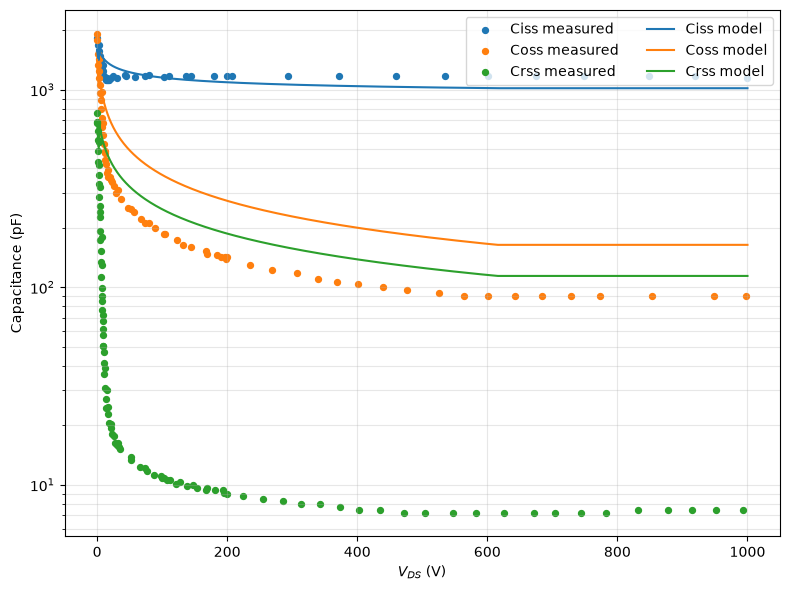

In [9]:
# Compare the fitted room-temperature Ciss, Coss, and Crss curves with both measured voltage ranges.
Vds_plot = torch.linspace(0.0, 1000.0, 1200, dtype=dtype, device=device).reshape(-1, 1)
Model_Cgd.eval()
cv_parameters.eval()
with torch.no_grad():
    Ciss_plot, Coss_plot, Crss_plot, _, _ = evaluate_cv(Vds_plot)

plt.figure(figsize=(8, 6))
for name in ["Ciss", "Coss", "Crss"]:
    part = cv_data[cv_data["capacitance"] == name]
    plt.scatter(part["Vds"], part["Capacitance_pF"], s=18, label=f"{name} measured")
for values, name in [(Ciss_plot, "Ciss model"), (Coss_plot, "Coss model"), (Crss_plot, "Crss model")]:
    plt.plot(Vds_plot.cpu(), (values * 1.0e12).cpu(), label=name)
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel("Capacitance (pF)")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


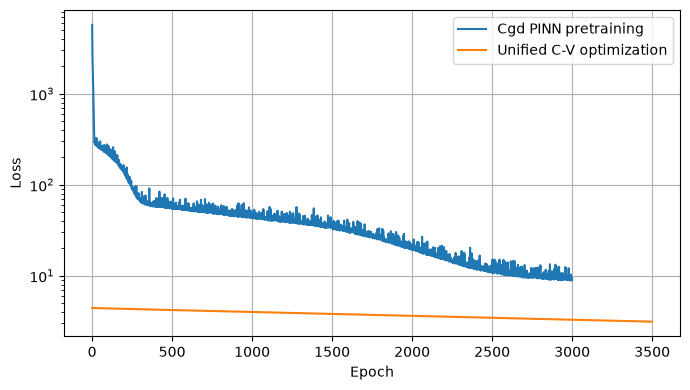

In [10]:
# Plot the room-temperature physics and C-V optimization losses.
plt.figure(figsize=(7, 4))
plt.plot(loss_gd_history, label="Cgd PINN pretraining")
plt.plot(cv_loss_history, label="Unified C-V optimization")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
